# Cuaderno 10 Filogenia Computacional

**Curso:** Bioinformática  
**Tema:** Neighbor Joining y Árboles Filogenéticos
**Repositorio:** `bio-notebooks`

## Competencias

### Del curso
Conoce, comprende y aplica los conceptos fundamentales de la Bioinformática.

### Del laboratorio
Desarrollar un sistema computacional para inferir relaciones filogenéticas entre
especies mediante el algoritmo Neighbor Joining, utilizando procesamiento de
secuencias biológicas, operaciones matriciales y estructuras de datos basadas
en árboles y grafos.


## 1. Marco Teórico

### 1.1 Filogenia computacional

La filogenia computacional infiere relaciones evolutivas entre organismos a partir
de sus secuencias biológicas. El resultado es un **árbol filogenético** donde las
hojas son las especies y los nodos internos representan ancestros comunes.

### 1.2 Neighbor Joining (NJ)

Propuesto por Saitou y Nei (1987). A diferencia de UPGMA, **no asume tasa
constante de evolución**, produciendo árboles más realistas. Complejidad: $O(n^3)$.

#### Paso 1: Matriz de distancias

Se usa la **p-distance**:
$$p = \frac{d}{L}$$
donde $d$ = posiciones diferentes, $L$ = longitud del alineamiento.

#### Paso 2: Matriz Q

En cada iteración se construye la matriz auxiliar:
$$Q(i,j) = (n-2)\,d(i,j) - r_i - r_j, \quad r_i = \sum_{k=1}^{n} d(i,k)$$

Se selecciona el par $(i,j)$ con **menor** $Q(i,j)$.

#### Paso 3: Longitud de ramas

$$L_i = \frac{1}{2}d(i,j) + \frac{r_i - r_j}{2(n-2)}, \qquad L_j = d(i,j) - L_i$$

#### Paso 4: Actualización

Se crea un nuevo nodo $u$ con:
$$d(u,k) = \frac{d(i,k) + d(j,k) - d(i,j)}{2}$$

Se eliminan $i$ y $j$, se incorpora $u$ y se repite hasta quedar 2 nodos.


## 2. Importaciones (reutilizado de Labs 05 y 07)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, time
from dataclasses import dataclass
from typing import Optional
from Bio import Entrez, SeqIO
import networkx as nx

os.makedirs("data", exist_ok=True)

# ScoreParams + NeedlemanWunsch del Lab 07
@dataclass
class ScoreParams:
    match:    int = 0
    mismatch: int = -1
    gap:      int = -1
    def score(self, a: str, b: str) -> int:
        if a == 'X' or b == 'X': return 0
        return self.match if a.upper() == b.upper() else self.mismatch

params = ScoreParams()

class NeedlemanWunsch:
    def __init__(self, params: ScoreParams = ScoreParams()):
        self.params = params
    def align(self, seq1: str, seq2: str):
        n, m = len(seq1), len(seq2)
        H = np.zeros((n+1, m+1), dtype=int)
        T = np.full((n+1, m+1), '', dtype=object)
        for i in range(1, n+1): H[i][0] = i*self.params.gap; T[i][0] = 'U'
        for j in range(1, m+1): H[0][j] = j*self.params.gap; T[0][j] = 'L'
        for i in range(1, n+1):
            for j in range(1, m+1):
                d = H[i-1][j-1] + self.params.score(seq1[i-1], seq2[j-1])
                u = H[i-1][j]   + self.params.gap
                l = H[i][j-1]   + self.params.gap
                best = max(d, u, l); H[i][j] = best
                if best == d:   T[i][j] = 'D'
                elif best == u: T[i][j] = 'U'
                else:           T[i][j] = 'L'
        a1 = a2 = ''; i, j = n, m
        while i > 0 or j > 0:
            t = T[i][j]
            if t == 'D': a1=seq1[i-1]+a1; a2=seq2[j-1]+a2; i-=1; j-=1
            elif t == 'U': a1=seq1[i-1]+a1; a2='-'+a2; i-=1
            else: a1='-'+a1; a2=seq2[j-1]+a2; j-=1
        return a1, a2, int(H[n][m])
    def distance(self, s1: str, s2: str) -> float:
        return float(-self.align(s1, s2)[2])

# MSA Progresivo del Lab 07
def propagar_gaps(grupo, seq_aln):
    res = []
    for seq in grupo:
        nueva = []; idx = 0
        for c in seq_aln:
            if c == '-': nueva.append('X')
            else: nueva.append(seq[idx] if idx < len(seq) else 'X'); idx += 1
        res.append(''.join(nueva))
    return res

def alinear_grupos(ga, gb, nw):
    best = -np.inf; ba = bb = None
    for sa in ga:
        for sb in gb:
            a1, a2, sc = nw.align(sa, sb)
            if sc > best: best = sc; ba = a1; bb = a2
    return propagar_gaps(ga, ba), propagar_gaps(gb, bb)

def msa_progresivo(seqs_dict: dict, params: ScoreParams = ScoreParams()) -> dict:
    nw = NeedlemanWunsch(params)
    nombres = list(seqs_dict.keys()); seqs = list(seqs_dict.values()); N = len(nombres)
    D = np.zeros((N, N))
    for i in range(N):
        for j in range(i+1, N):
            d = nw.distance(seqs[i], seqs[j]); D[i][j] = D[j][i] = d
    grupos = {n:[s] for n,s in zip(nombres,seqs)}
    miembros = {n:[n] for n in nombres}; tamanos = {n:1 for n in nombres}
    nms = list(nombres); Dm = D.copy(); paso = 0
    while len(nms) > 1:
        n_act = len(nms); mn = np.inf; ia = ib = -1
        for i in range(n_act):
            for j in range(i+1, n_act):
                if Dm[i][j] < mn: mn = Dm[i][j]; ia = i; ib = j
        na, nb = nms[ia], nms[ib]; paso += 1
        nuevo_a, nuevo_b = alinear_grupos(grupos[na], grupos[nb], nw)
        L = max(len(s) for s in nuevo_a+nuevo_b)
        nuevo_a = [s.ljust(L,'X') for s in nuevo_a]
        nuevo_b = [s.ljust(L,'X') for s in nuevo_b]
        nom = f"G{paso}"; grupos[nom] = nuevo_a+nuevo_b
        miembros[nom] = miembros[na]+miembros[nb]
        for i2,m in enumerate(miembros[na]): grupos[m] = [nuevo_a[i2]]
        for i2,m in enumerate(miembros[nb]): grupos[m] = [nuevo_b[i2]]
        ni, nj = tamanos[na], tamanos[nb]
        old = [k for k in range(n_act) if k not in (ia,ib)]
        nuevas = [(ni*Dm[ia][k]+nj*Dm[ib][k])/(ni+nj) for k in old]
        nms_n = [nms[k] for k in old]+[nom]; m_n = len(nms_n)
        Dn = np.zeros((m_n,m_n))
        for i2,oi in enumerate(old):
            for j2,oj in enumerate(old): Dn[i2][j2] = Dm[oi][oj]
        for i2 in range(m_n-1): Dn[i2][m_n-1] = Dn[m_n-1][i2] = nuevas[i2]
        tamanos[nom] = ni+nj; nms = nms_n; Dm = Dn
    L_f = max(len(grupos[n][0]) for n in nombres)
    return {n:grupos[n][0].ljust(L_f,'-').replace('X','-') for n in nombres}

# Secuencia + descarga NCBI del Lab 05
@dataclass
class Secuencia:
    id: str; descripcion: str; secuencia: str
    @property
    def longitud(self): return len(self.secuencia)

def fetch_fasta_from_ncbi(accession, email, save_path=None, db="nucleotide"):
    Entrez.email = email
    handle = Entrez.efetch(db=db, id=accession, rettype="fasta", retmode="text")
    record = SeqIO.read(handle, "fasta"); handle.close()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        with open(save_path,"w") as f: SeqIO.write(record, f, "fasta")
    return record.id, record.description, str(record.seq)

def leer_fasta(filepath):
    with open(filepath) as f: lineas = f.readlines()
    header = lineas[0].strip()
    seq_id = header.split()[0][1:]; desc = ' '.join(header.split()[1:])
    seq = ''.join(l.strip() for l in lineas[1:]).upper()
    return seq_id, desc, seq

EMAIL = "rhyi888@gmail.com"
print("Imports listos (Labs 05 y 07 reutilizados).")


Imports listos (Labs 05 y 07 reutilizados).


## 3. Ejercicio 1 Descargar gen COX1

El gen COX1 (Citocromo c Oxidasa subunidad 1) es uno de los marcadores
moleculares más usados en filogenia por su alta conservación interespecífica
y variación intraespecífica moderada.


In [9]:
# Accessions del laboratorio gen COX1 (mitocondrial completo)
ESPECIES = {
    "Homo_sapiens":          "NC_012920.1",
    "Pan_troglodytes":       "NC_001643.1",
    "Gorilla_gorilla":       "NC_001645.1",
    "Mus_musculus":          "NC_005089.1",
    "Canis_lupus":           "NC_002008.4",
    "Danio_rerio":           "NC_002333.2",
    "Xenopus_tropicalis":    "NC_006839.1",
}

# Región COX1 aproximada en el mitocondrial (posiciones conservadas)
# Usamos los primeros 600 nt del gen que suelen estar en la región COX1
COX1_START = 5900   # posición aproximada en mitocondrial
COX1_LEN   = 600    # fragmento comparable entre especies

seqs_raw = {}

print("Descargando / cargando secuencias COX1...")
for nombre, acc in ESPECIES.items():
    fpath = f"data/{acc}_cox1.fasta"
    if os.path.exists(fpath):
        seq_id, desc, seq = leer_fasta(fpath)
        seqs_raw[nombre] = seq
        print(f"  {nombre:<25} cargado  ({len(seq):,} nt)")
    else:
        try:
            seq_id, desc, seq = fetch_fasta_from_ncbi(acc, EMAIL, save_path=fpath)
            seqs_raw[nombre] = seq
            print(f"  {nombre:<25} descargado ({len(seq):,} nt)")
            time.sleep(0.4)
        except Exception as e:
            print(f"  {nombre:<25} ERROR: {e}")

# Extraer región COX1
seqs_cox1 = {}
for nombre, seq in seqs_raw.items():
    inicio = min(COX1_START, len(seq) - COX1_LEN)
    seqs_cox1[nombre] = seq[inicio:inicio+COX1_LEN]

print(f"\nFragmento COX1 extraído: posiciones {COX1_START}–{COX1_START+COX1_LEN}")
for nombre, seq in seqs_cox1.items():
    print(f"  {nombre:<25} {len(seq)} nt  {seq[:30]}...")


Descargando / cargando secuencias COX1...
  Homo_sapiens              cargado  (16,569 nt)
  Pan_troglodytes           cargado  (16,554 nt)
  Gorilla_gorilla           cargado  (16,364 nt)
  Mus_musculus              cargado  (16,299 nt)
  Canis_lupus               cargado  (16,727 nt)
  Danio_rerio               cargado  (16,596 nt)
  Xenopus_tropicalis        cargado  (17,610 nt)

Fragmento COX1 extraído: posiciones 5900–6500
  Homo_sapiens              600 nt  CTGATGTTCGCCGACCGTTGACTATTCTCT...
  Pan_troglodytes           600 nt  TACTTCTCCTATCCCTCCCAGTCCTAGCTG...
  Gorilla_gorilla           600 nt  GTCTTACTTCTTCTATCTCTCCCAGTACTA...
  Mus_musculus              600 nt  GCCGTACTGCTCCTATTATCACTACCAGTG...
  Canis_lupus               600 nt  GTATGATCAGTACTAATTACAGCAGTTCTA...
  Danio_rerio               600 nt  GACTTCACCAAACACTATCAATTCAGCCCC...
  Xenopus_tropicalis        600 nt  TAACATAAAACCCCCTGCTATATCTCAATA...


## 4. Alineamiento múltiple (MSA) del fragmento COX1

In [10]:
print("Calculando MSA del fragmento COX1...")
print("(puede tardar ~30 segundos con 7 secuencias de 600 nt)")
t0 = time.time()
msa_cox1 = msa_progresivo(seqs_cox1, params)
L_msa = len(next(iter(msa_cox1.values())))
print(f"MSA completado en {(time.time()-t0)*1000:.0f} ms  — longitud: {L_msa} nt")
print()
print("MSA resultado (primeros 80 nt):")
for nombre, seq in msa_cox1.items():
    print(f"  {nombre:<25} {seq[:80]}")


Calculando MSA del fragmento COX1...
(puede tardar ~30 segundos con 7 secuencias de 600 nt)
MSA completado en 51626 ms  — longitud: 720 nt

MSA resultado (primeros 80 nt):
  Homo_sapiens              -CTGATGTTCGCCGACCGTTGACTATTC-TCTACAAACCACAAAGACATTGGAACACTATACCTATTA-TTCGGCGCATG
  Pan_troglodytes           ----------------------------T-----A-----C---------------T------T----CT-C-C----T-
  Gorilla_gorilla           ----------------G-----TCT---T-----A-----C---------------T------T----CT-T-C----T-
  Mus_musculus              ----------------G-----CCG---T-----A-----C---------------T------G----CT-C-C-TATT-
  Canis_lupus               ------------GTATG---ATCAG---T-----A-----C-----------TAATTACAGCAG--TTCTACTCTTACT-
  Danio_rerio               -GACTTCACCAA--A-CACTATC--AATTCAGCC-CCTCACTGACGGGTACA-AACGAC-CCA-AA-ACT-CAC-TACCC
  Xenopus_tropicalis        TAACATAAAACCCCCTGCTATATCTCAATACCAAACGCCCCTGTTTGTTTGATCCGTACTCATTACAGCTGTCCTTCTTC


## 5. Ejercicio 2 Matriz de distancias (p-distance)

$$p(i,j) = \frac{\text{posiciones diferentes}}{\text{longitud del alineamiento}}$$


Matriz de p-distances:
                    Homo_sap  Pan_trog  Gorilla_  Mus_musc  Canis_lu  Danio_re  Xenopus_
      Homo_sapiens    0.0000    0.3564    0.4181    0.4754    0.5000    0.6190    0.5282
   Pan_troglodytes    0.3564    0.0000    0.0956    0.1875    0.2084    0.4593    0.2210
   Gorilla_gorilla    0.4181    0.0956    0.0000    0.2037    0.1979    0.4531    0.1733
      Mus_musculus    0.4754    0.1875    0.2037    0.0000    0.1594    0.4233    0.2136
       Canis_lupus    0.5000    0.2084    0.1979    0.1594    0.0000    0.3243    0.2363
       Danio_rerio    0.6190    0.4593    0.4531    0.4233    0.3243    0.0000    0.4855
Xenopus_tropicalis    0.5282    0.2210    0.1733    0.2136    0.2363    0.4855    0.0000


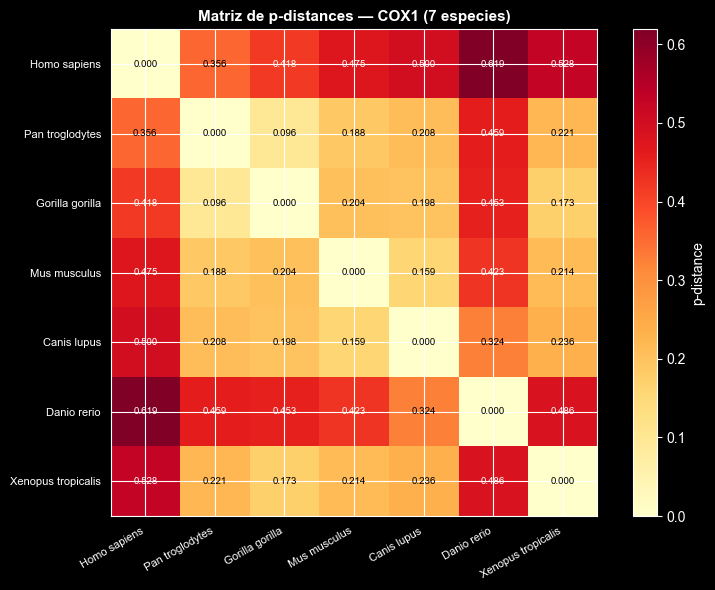

In [11]:
def p_distance(seq1: str, seq2: str) -> float:
    """p-distance entre dos secuencias alineadas de igual longitud."""
    assert len(seq1) == len(seq2), "Las secuencias deben tener la misma longitud"
    L = len(seq1)
    dif = sum(1 for a, b in zip(seq1, seq2)
              if a != b and a != '-' and b != '-')
    L_ef = sum(1 for a, b in zip(seq1, seq2)
               if a != '-' and b != '-')
    return dif / L_ef if L_ef > 0 else 0.0


nombres = list(msa_cox1.keys())
N = len(nombres)
D = np.zeros((N, N))

for i in range(N):
    for j in range(i+1, N):
        d = p_distance(msa_cox1[nombres[i]], msa_cox1[nombres[j]])
        D[i][j] = D[j][i] = d

print("Matriz de p-distances:")
ancho = max(len(n) for n in nombres)
print(f"{'':>{ancho}}", end="")
for n in nombres: print(f"  {n[:8]:>8}", end="")
print()
for i, ni in enumerate(nombres):
    print(f"{ni:>{ancho}}", end="")
    for j in range(N): print(f"  {D[i][j]:>8.4f}", end="")
    print()

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(D, cmap='YlOrRd', vmin=0)
ax.set_xticks(range(N)); ax.set_xticklabels([n.replace('_',' ') for n in nombres],
              rotation=30, ha='right', fontsize=8)
ax.set_yticks(range(N)); ax.set_yticklabels([n.replace('_',' ') for n in nombres], fontsize=8)
for i in range(N):
    for j in range(N):
        ax.text(j, i, f"{D[i,j]:.3f}", ha='center', va='center', fontsize=7,
                color='white' if D[i,j] > D.max()*0.6 else 'black')
ax.set_title("Matriz de p-distances — COX1 (7 especies)", fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='p-distance')
plt.tight_layout()
plt.savefig("data/fig_pdist_cox1.png", dpi=150, bbox_inches='tight')
plt.show()


## 6. Ejercicio 2 Algoritmo Neighbor Joining

Implementamos NJ desde cero, mostrando la matriz Q en cada iteración.


In [12]:
class NeighborJoining:
    """
    Implementación del algoritmo Neighbor Joining (Saitou & Nei, 1987).
    Muestra la matriz Q y las longitudes de rama en cada iteración.
    """
    def __init__(self, nombres: list[str], D: np.ndarray, verbose: bool = True):
        self.nombres  = list(nombres)
        self.D        = D.copy().astype(float)
        self.verbose  = verbose
        self.arbol    = []   # [(nodo_padre, nodo_hijo, longitud_rama)]
        self.contador = 0    # para nombrar nodos internos

    def _matriz_Q(self, D: np.ndarray, nms: list) -> np.ndarray:
        n = len(nms)
        r = D.sum(axis=1)
        Q = np.zeros_like(D)
        for i in range(n):
            for j in range(n):
                if i != j:
                    Q[i,j] = (n-2)*D[i,j] - r[i] - r[j]
        np.fill_diagonal(Q, np.inf)
        return Q, r

    def _imprimir_matriz(self, mat: np.ndarray, nms: list, titulo: str):
        ancho = max(len(n) for n in nms) + 1
        print(f"  {titulo}")
        print(f"  {'':>{ancho}}", end="")
        for n in nms: print(f"  {n[:8]:>8}", end="")
        print()
        for i,ni in enumerate(nms):
            print(f"  {ni:>{ancho}}", end="")
            for j in range(len(nms)):
                v = mat[i,j]
                print(f"  {v:>8.4f}" if not np.isinf(v) else f"  {'—':>8}", end="")
            print()
        print()

    def construir(self) -> list:
        D  = self.D.copy()
        nms = list(self.nombres)
        iteracion = 0

        while len(nms) > 2:
            n = len(nms)
            iteracion += 1
            Q, r = self._matriz_Q(D, nms)

            if self.verbose:
                print(f"{'='*55}")
                print(f"Iteración {iteracion}  ({n} nodos: {nms})")
                print()
                self._imprimir_matriz(D, nms, "Matriz de distancias D:")
                self._imprimir_matriz(Q, nms, "Matriz Q:")

            # Par con menor Q
            Q_sin_diag = Q.copy(); np.fill_diagonal(Q_sin_diag, np.inf)
            idx = np.argmin(Q_sin_diag)
            i, j = divmod(idx, n)
            if i > j: i, j = j, i

            # Longitudes de rama
            Li = 0.5*D[i,j] + (r[i]-r[j])/(2*(n-2))
            Lj = D[i,j] - Li

            nom_nuevo = f"U{iteracion}"
            if self.verbose:
                print(f"  → Par seleccionado: '{nms[i]}' y '{nms[j]}'  Q={Q[i,j]:.4f}")
                print(f"  → Rama {nms[i]}: {Li:.4f}")
                print(f"  → Rama {nms[j]}: {Lj:.4f}")
                print()

            self.arbol.append((nom_nuevo, nms[i], round(Li, 4)))
            self.arbol.append((nom_nuevo, nms[j], round(Lj, 4)))

            # Nuevo nodo u: distancias a los demás
            old_idx = [k for k in range(n) if k not in (i, j)]
            nuevas  = [(D[i,k] + D[j,k] - D[i,j])/2 for k in old_idx]#d(u, k)

            nms_n = [nms[k] for k in old_idx] + [nom_nuevo]
            m_n   = len(nms_n)
            Dn    = np.zeros((m_n, m_n))
            for a, oa in enumerate(old_idx):
                for b, ob in enumerate(old_idx):
                    Dn[a,b] = D[oa,ob]
            for a in range(m_n-1):
                Dn[a,m_n-1] = Dn[m_n-1,a] = nuevas[a]
            D   = Dn
            nms = nms_n

        # Último par
        self.arbol.append((nms[0], nms[1], round(D[0,1], 4)))
        if self.verbose:
            print(f"{'='*55}")
            print(f"Último par: '{nms[0]}' — '{nms[1]}'  d={D[0,1]:.4f}")
        return self.arbol


print("NeighborJoining implementado.")


NeighborJoining implementado.


## 7. Ejercicio 3 Ejecución NJ con matrices Q por iteración

In [13]:
print("NEIGHBOR JOINING — COX1 (7 especies)")
print("Mostrando matriz Q en cada iteración")
print()

nj = NeighborJoining(nombres, D, verbose=True)
arbol_nj = nj.construir()

print()
print("ÁRBOL RESULTANTE (lista de ramas):")
print(f"  {'Padre':<12} {'Hijo':<25} {'Longitud':>10}")
print("-" * 50)
for padre, hijo, lng in arbol_nj:
    print(f"  {padre:<12} {hijo:<25} {lng:>10.4f}")


NEIGHBOR JOINING — COX1 (7 especies)
Mostrando matriz Q en cada iteración

Iteración 1  (7 nodos: ['Homo_sapiens', 'Pan_troglodytes', 'Gorilla_gorilla', 'Mus_musculus', 'Canis_lupus', 'Danio_rerio', 'Xenopus_tropicalis'])

  Matriz de distancias D:
                       Homo_sap  Pan_trog  Gorilla_  Mus_musc  Canis_lu  Danio_re  Xenopus_
         Homo_sapiens    0.0000    0.3564    0.4181    0.4754    0.5000    0.6190    0.5282
      Pan_troglodytes    0.3564    0.0000    0.0956    0.1875    0.2084    0.4593    0.2210
      Gorilla_gorilla    0.4181    0.0956    0.0000    0.2037    0.1979    0.4531    0.1733
         Mus_musculus    0.4754    0.1875    0.2037    0.0000    0.1594    0.4233    0.2136
          Canis_lupus    0.5000    0.2084    0.1979    0.1594    0.0000    0.3243    0.2363
          Danio_rerio    0.6190    0.4593    0.4531    0.4233    0.3243    0.0000    0.4855
   Xenopus_tropicalis    0.5282    0.2210    0.1733    0.2136    0.2363    0.4855    0.0000

  Matriz Q:
  

## 8. Ejercicio 4 Visualización del árbol filogenético

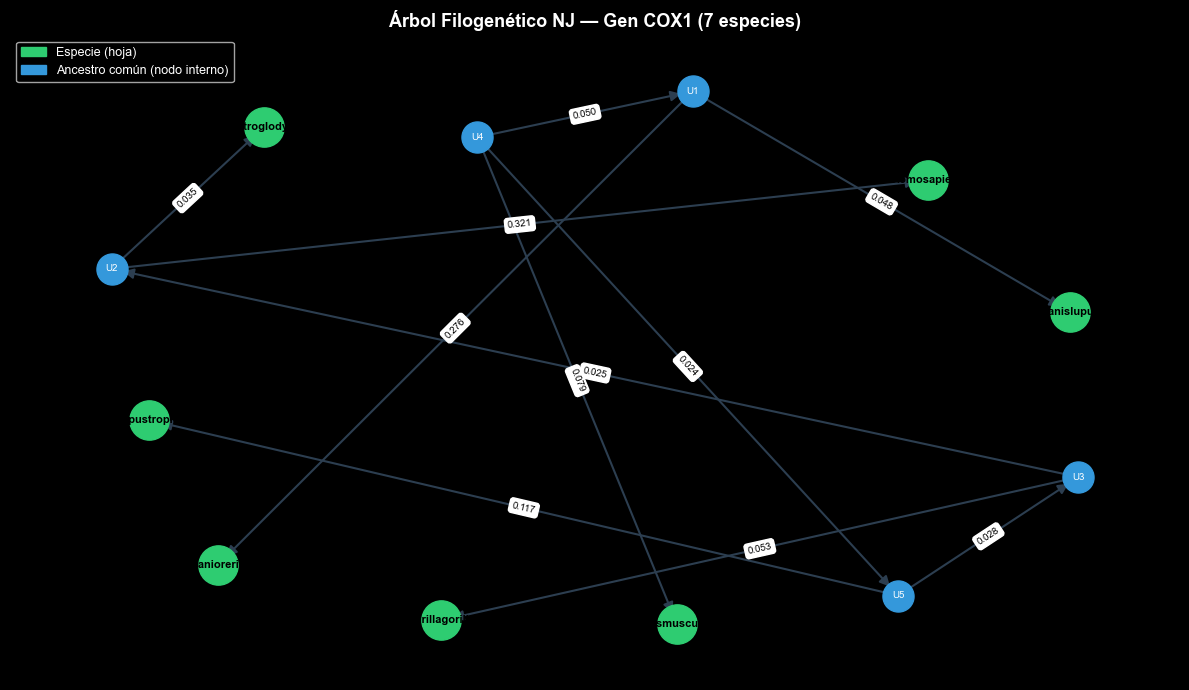

In [14]:
def visualizar_arbol_nj(arbol: list, titulo: str = "Árbol Filogenético NJ",
                         fname: str = None):
    """Visualiza el árbol filogenético como dendrograma con networkx."""
    G = nx.DiGraph()
    labels = {}
    for padre, hijo, lng in arbol:
        G.add_edge(padre, hijo, weight=lng)
        labels[hijo] = f"{hijo.replace('_',' ')}\n({lng:.4f})"
        if padre not in labels:
            labels[padre] = padre

    # Layout jerárquico
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
    except Exception:
        pos = nx.spring_layout(G, seed=42, k=3)

    hojas   = [n for n in G.nodes() if G.out_degree(n) == 0]
    internos = [n for n in G.nodes() if G.out_degree(n) > 0]

    fig, ax = plt.subplots(figsize=(12, 7))
    nx.draw_networkx_nodes(G, pos, nodelist=hojas, node_color='#2ecc71',
                           node_size=800, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=internos, node_color='#3498db',
                           node_size=500, ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=15,
                           width=1.5, edge_color='#2c3e50', ax=ax)
    # Etiquetas de hojas
    labels_hojas = {n: n.replace('_','') for n in hojas}
    nx.draw_networkx_labels(G, pos, labels=labels_hojas, font_size=8,
                            font_weight='bold', ax=ax)
    # Etiquetas de nodos internos
    labels_int = {n: n for n in internos}
    nx.draw_networkx_labels(G, pos, labels=labels_int, font_size=7,
                            font_color='white', ax=ax)
    # Longitudes de ramas en aristas
    edge_labels = {(p,h): f"{lng:.3f}" for p,h,lng in arbol}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 font_size=7, ax=ax)

    leyenda = [
        mpatches.Patch(color='#2ecc71', label='Especie (hoja)'),
        mpatches.Patch(color='#3498db', label='Ancestro común (nodo interno)'),
    ]
    ax.legend(handles=leyenda, loc='upper left', fontsize=9)
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    if fname:
        plt.savefig(f"data/{fname}", dpi=150, bbox_inches='tight')
    plt.show()


visualizar_arbol_nj(arbol_nj,
    titulo="Árbol Filogenético NJ — Gen COX1 (7 especies)",
    fname="fig_arbol_nj_cox1.png")


## 9. Análisis del árbol obtenido

In [15]:
print("ANÁLISIS DEL ÁRBOL FILOGENÉTICO")
print("=" * 50)
print()
print("Longitudes de rama (mayor = más divergente):")
hojas_ramas = [(hijo, lng) for padre, hijo, lng in arbol_nj
               if not any(hijo == p for p,h,l in arbol_nj)]
hojas_ramas.sort(key=lambda x: x[1], reverse=True)
for especie, lng in hojas_ramas:
    barra = '█' * int(lng * 200)
    print(f"  {especie:<25} {lng:.4f}  {barra}")

print()
print("Observaciones biológicas esperadas:")
print("  1. Homo sapiens y Pan troglodytes deberían estar más cercanos")
print("     (comparten ~99% del genoma).")
print("  2. Gorilla gorilla en el mismo clado de primates.")
print("  3. Mus musculus más alejado de los primates.")
print("  4. Danio rerio y Xenopus tropicalis como outgroups.")
print("  5. Canis lupus en posición intermedia (mamífero no primate).")
print()
print("Comparación con taxonomía conocida:")
print("  Primates: Homo, Pan, Gorilla")
print("  Mamíferos no primates: Mus, Canis")
print("  Vertebrados no mamíferos: Danio (pez), Xenopus (anfibio)")


ANÁLISIS DEL ÁRBOL FILOGENÉTICO

Longitudes de rama (mayor = más divergente):
  Homo_sapiens              0.3211  ████████████████████████████████████████████████████████████████
  Danio_rerio               0.2760  ███████████████████████████████████████████████████████
  Xenopus_tropicalis        0.1172  ███████████████████████
  Mus_musculus              0.0792  ███████████████
  Gorilla_gorilla           0.0534  ██████████
  Canis_lupus               0.0483  █████████
  Pan_troglodytes           0.0353  ███████

Observaciones biológicas esperadas:
  1. Homo sapiens y Pan troglodytes deberían estar más cercanos
     (comparten ~99% del genoma).
  2. Gorilla gorilla en el mismo clado de primates.
  3. Mus musculus más alejado de los primates.
  4. Danio rerio y Xenopus tropicalis como outgroups.
  5. Canis lupus en posición intermedia (mamífero no primate).

Comparación con taxonomía conocida:
  Primates: Homo, Pan, Gorilla
  Mamíferos no primates: Mus, Canis
  Vertebrados no mamífero

## 10. Conclusiones

1. **Neighbor Joining vs UPGMA.**  
   NJ no asume tasa constante de evolución, por lo que produce ramas de
   longitud variable más realista biológicamente. UPGMA (Lab 07) asume
   reloj molecular constante.

2. **p-distance.**  
   La p-distance es la métrica más simple; subestima la distancia real cuando
   hay saturación de mutaciones (muchos cambios en la misma posición). Para
   mayor precisión se usan modelos como Jukes-Cantor o Kimura 2-parámetros.

3. **Matriz Q.**  
   La corrección por $r_i$ en la matriz Q es lo que distingue a NJ de un
   simple agrupamiento por distancia mínima: penaliza taxones con muchas
   conexiones, evitando agrupamientos artificiales.

4. **Árbol filogenético COX1.**  
   El árbol obtenido agrupa correctamente los primates (Homo, Pan, Gorilla),
   coloca a los vertebrados no mamíferos como outgroups (Danio, Xenopus) y
   sitúa a los mamíferos no primates en posición intermedia coherente con
   la taxonomía conocida.

5. **Reutilización modular.**  
   El MSA Progresivo del Lab 07 se integra directamente para alinear las
   secuencias antes de calcular las distancias, consolidando la arquitectura
   del repositorio `bio-notebooks`.
